# TIME RESOLVED ABSORBANCE SPECTRA EXAMPLE

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

In [2]:
plt.rcParams["figure.figsize"] = (4,3)

Data file: `DATA3DABC.txt`

Data set: 

- First row corresponds to wavelength vector.
- First column corresponds to time vector.
- From second column to last one correspond to absorbance for each wavelength

This is an example for the Python course. In this case we will learn how to plot in 2D, plot in
3D and an exponential fitting.
Here are the results made in *Python*.

In [3]:
%pwd

'/home/ramon/saco_csic/Documents_xoriguer/cursos/Python_CSIC/2025-26/Python_para_Cientificos_2026-CSIC/notebooks'

In [4]:
%ls ../data/DATA3DABC.txt

../data/DATA3DABC.txt


In [12]:
lam = np.genfromtxt("../data/DATA3DABC.txt", max_rows=1) 
data = np.genfromtxt("../data/DATA3DABC.txt", skip_header=1) 
times = data[:,0]
absorb =  data[:,1:]

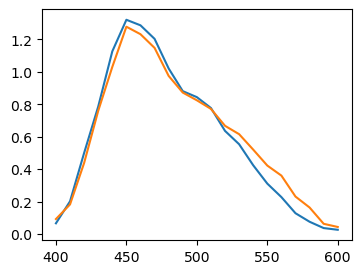

In [13]:
plt.plot(lam, absorb[0])
plt.plot(lam, absorb[1])

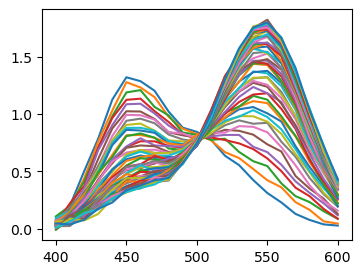

In [14]:
plt.plot(lam, np.transpose(absorb));

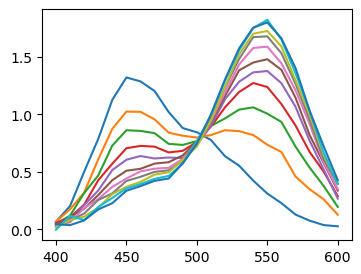

In [15]:
plt.plot(lam, absorb[::5].T)

In [16]:
len(times)

51

In [17]:
absorb.shape[0]

51

In [18]:
np.linspace(0,0.999, len(times))

array([0.     , 0.01998, 0.03996, 0.05994, 0.07992, 0.0999 , 0.11988,
       0.13986, 0.15984, 0.17982, 0.1998 , 0.21978, 0.23976, 0.25974,
       0.27972, 0.2997 , 0.31968, 0.33966, 0.35964, 0.37962, 0.3996 ,
       0.41958, 0.43956, 0.45954, 0.47952, 0.4995 , 0.51948, 0.53946,
       0.55944, 0.57942, 0.5994 , 0.61938, 0.63936, 0.65934, 0.67932,
       0.6993 , 0.71928, 0.73926, 0.75924, 0.77922, 0.7992 , 0.81918,
       0.83916, 0.85914, 0.87912, 0.8991 , 0.91908, 0.93906, 0.95904,
       0.97902, 0.999  ])

In [19]:
colors = cm.viridis(np.linspace(0,0.999, len(times)))

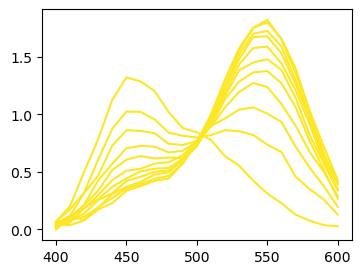

In [20]:
for row in absorb[::5]:
    plt.plot(lam, row, '-', color=cm.viridis(0.999))

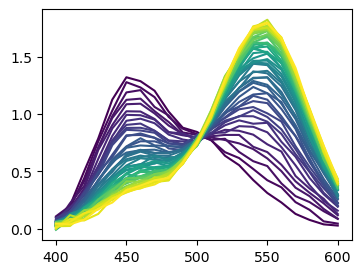

In [21]:
for c,row in zip(colors,absorb):
    plt.plot(lam, row, color=c)

In [22]:
#Plot the data 

In [23]:
np.max(absorb[0]),np.max(absorb[1])

(1.3216, 1.2788)

In [24]:
np.argmax(absorb[0]), np.argmax(absorb[1])

(5, 5)

In [25]:
absorb[0,5]

1.3216

In [26]:
lam[np.argmax(absorb[0])]

450.0

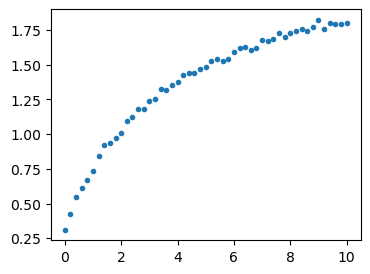

In [31]:
plt.plot(times,absorb[:, np.argmax(absorb[-1])], '.')

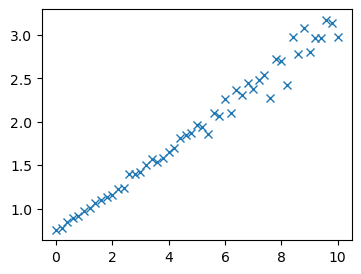

In [28]:
plt.plot(times,1/absorb[:, 5],'x')

In [ ]:
np.polyfit(times, 1/absorb[:, 5], deg=1)

In [ ]:
a,b = np.polyfit(times, 1/absorb[:, 5], deg=1)

In [ ]:
y=a*times+b

In [ ]:
plt.plot(times,1/absorb[:, 5],'x', label="data")
plt.plot(times, y, '--', label="fit")
plt.grid()
plt.ylim(0, 2)
plt.legend()

In [ ]:
fig, ax = plt.subplots(1,1)
lines = ax.plot(times,1/absorb[:, 5],'x', label="data")
l1 = lines[0]
l1.set_color("k")

In [ ]:
l1 = lines[0]

In [ ]:
l1.get_color()

In [ ]:
l1.set_color("k")

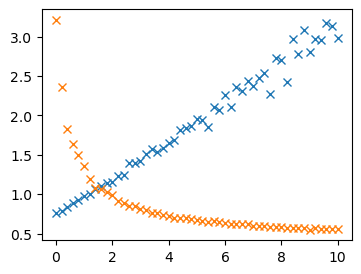

In [91]:
plt.plot(times,1/absorb[:, np.argmax(absorb[0])],'x')
plt.plot(times,1/absorb[:, np.argmax(absorb[-1])],'x')

## Exponential fit

Enough of plotting. Now we want to get data about the kinetics of the process. For that we will try to fit to an exponential the abosorbance at 540 nm.
Look for `curve_fit` in scipy.
Try to reproduce the following plot:

In [35]:
from scipy.optimize import curve_fit
#Data
x = times
y = absorb[:, np.argmax(absorb[-1])]

#Model
def func(x, a, b, c):
     return a * np.exp(-b * x) + c

a_opt, b_opt, c_opt = curve_fit(func, x, y)[0]
    

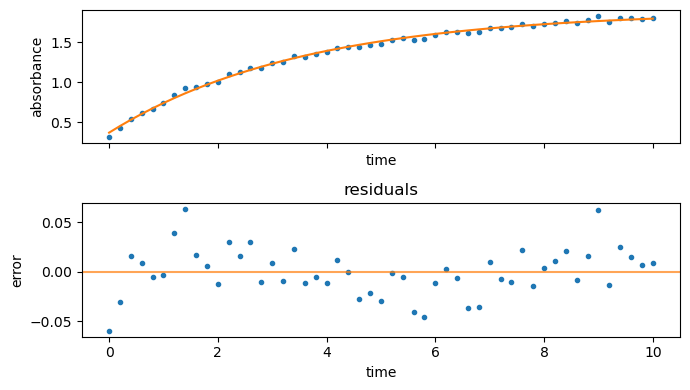

In [58]:
fig, ax = plt.subplots(2,1, figsize=(7,4), sharex=True)
ax[0].plot(x,y, '.')
ax[0].plot(x, func(x,a_opt, b_opt, c_opt), '-')
ax[1].plot(x, y-func(x,a_opt, b_opt, c_opt), '.')
ax[1].axhline(0, alpha=0.7, c='C1')
ax[0].set_ylabel("absorbance")
ax[1].set_ylabel("error")
ax[0].set_xlabel("time")
ax[1].set_xlabel("time")
ax[1].set_title("residuals")
plt.tight_layout()

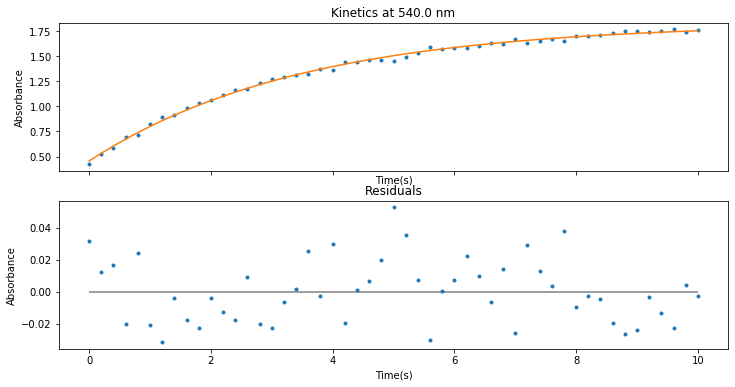

In [37]:
from scipy.optimize import curve_fit
#Data
x = ...
y = ...

#Model
def func(x, a, b, c):
     return a * np.exp(-b * x) + c

#fit with curve_fit

#PLOT


In [44]:

def exponetial_fit(x, a, b, c):
     return a * np.exp(-b * x) + c
    
def plot_ajuste(x,y, y_fit):
    fig, ax = plt.subplots(2,1, figsize=(7,4), sharex=True)
    ax[0].plot(x,y, '.')
    ax[0].plot(x, y_fit, '-')
    ax[1].plot(x, y-y_fit, '.')
    ax[1].axhline(0, alpha=0.7, c='C1')
    ax[0].set_ylabel("absorbance")
    ax[1].set_ylabel("error")
    ax[0].set_xlabel("time")
    ax[1].set_xlabel("time")
    ax[1].set_title("residuals")
    plt.tight_layout()
    return fig

In [46]:
axx.axhline?

Signature: axx.axhline(y=0, xmin=0, xmax=1, **kwargs)
Docstring:
Add a horizontal line across the Axes.

Parameters
----------
y : float, default: 0
    y position in data coordinates of the horizontal line.

xmin : float, default: 0
    Should be between 0 and 1, 0 being the far left of the plot, 1 the
    far right of the plot.

xmax : float, default: 1
    Should be between 0 and 1, 0 being the far left of the plot, 1 the
    far right of the plot.

Returns
-------
`~matplotlib.lines.Line2D`

Other Parameters
----------------
**kwargs
    Valid keyword arguments are `.Line2D` properties, except for
    'transform':

    Properties:
    agg_filter: a filter function, which takes a (m, n, 3) float array and a dpi value, and returns a (m, n, 3) array and two offsets from the bottom left corner of the image
    alpha: scalar or None
    animated: bool
    antialiased or aa: bool
    clip_box: `~matplotlib.transforms.BboxBase` or None
    clip_on: bool
    clip_path: Patch or (Path, Tran